In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(
    context="paper",
    style="whitegrid",
    palette="colorblind",
    font="sans-serif",
    font_scale=1.0,
    rc={
        "figure.dpi": 300,
        "savefig.dpi": 300,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.labelsize": 8,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "legend.fontsize": 7,
        "axes.titlesize": 9,
    },
)

In [2]:
df = pd.read_csv(Path.cwd().parent / 'story_summary.csv')

df_test = df[df['split'].isin(['validation', 'test-interpolation', 'test-extrapolation'])].copy()

df_test['split'] = df_test['split'].str.replace('test-', 'Test ').str.title()
df_test["family"] = df_test.apply(
    lambda row: row["method"] if row["family"] == "baseline" else row["family"],
    axis=1
)

df_test.head(6)

,method,family,split,num_runs,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std
0,MeanBaseline,MeanBaseline,Test Extrapolation,3,0.262807,0.0,0.303018,0.0,-0.030171,0.0
1,MeanBaseline,MeanBaseline,Test Interpolation,3,0.277203,0.0,0.320281,0.0,-0.002461,0.0
3,MeanBaseline,MeanBaseline,Validation,3,0.255000,0.0,0.301081,0.0,-0.016466,0.0
4,PlanLengthBaseline,PlanLengthBaseline,Test Extrapolation,3,0.551345,0.0,0.641309,0.0,-3.614319,0.0
5,PlanLengthBaseline,PlanLengthBaseline,Test Interpolation,3,0.263914,0.0,0.306298,0.0,0.083161,0.0
7,PlanLengthBaseline,PlanLengthBaseline,Validation,3,0.262769,0.0,0.311644,0.0,-0.089040,0.0


/tmp/ipykernel_13331/3624518666.py:65: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


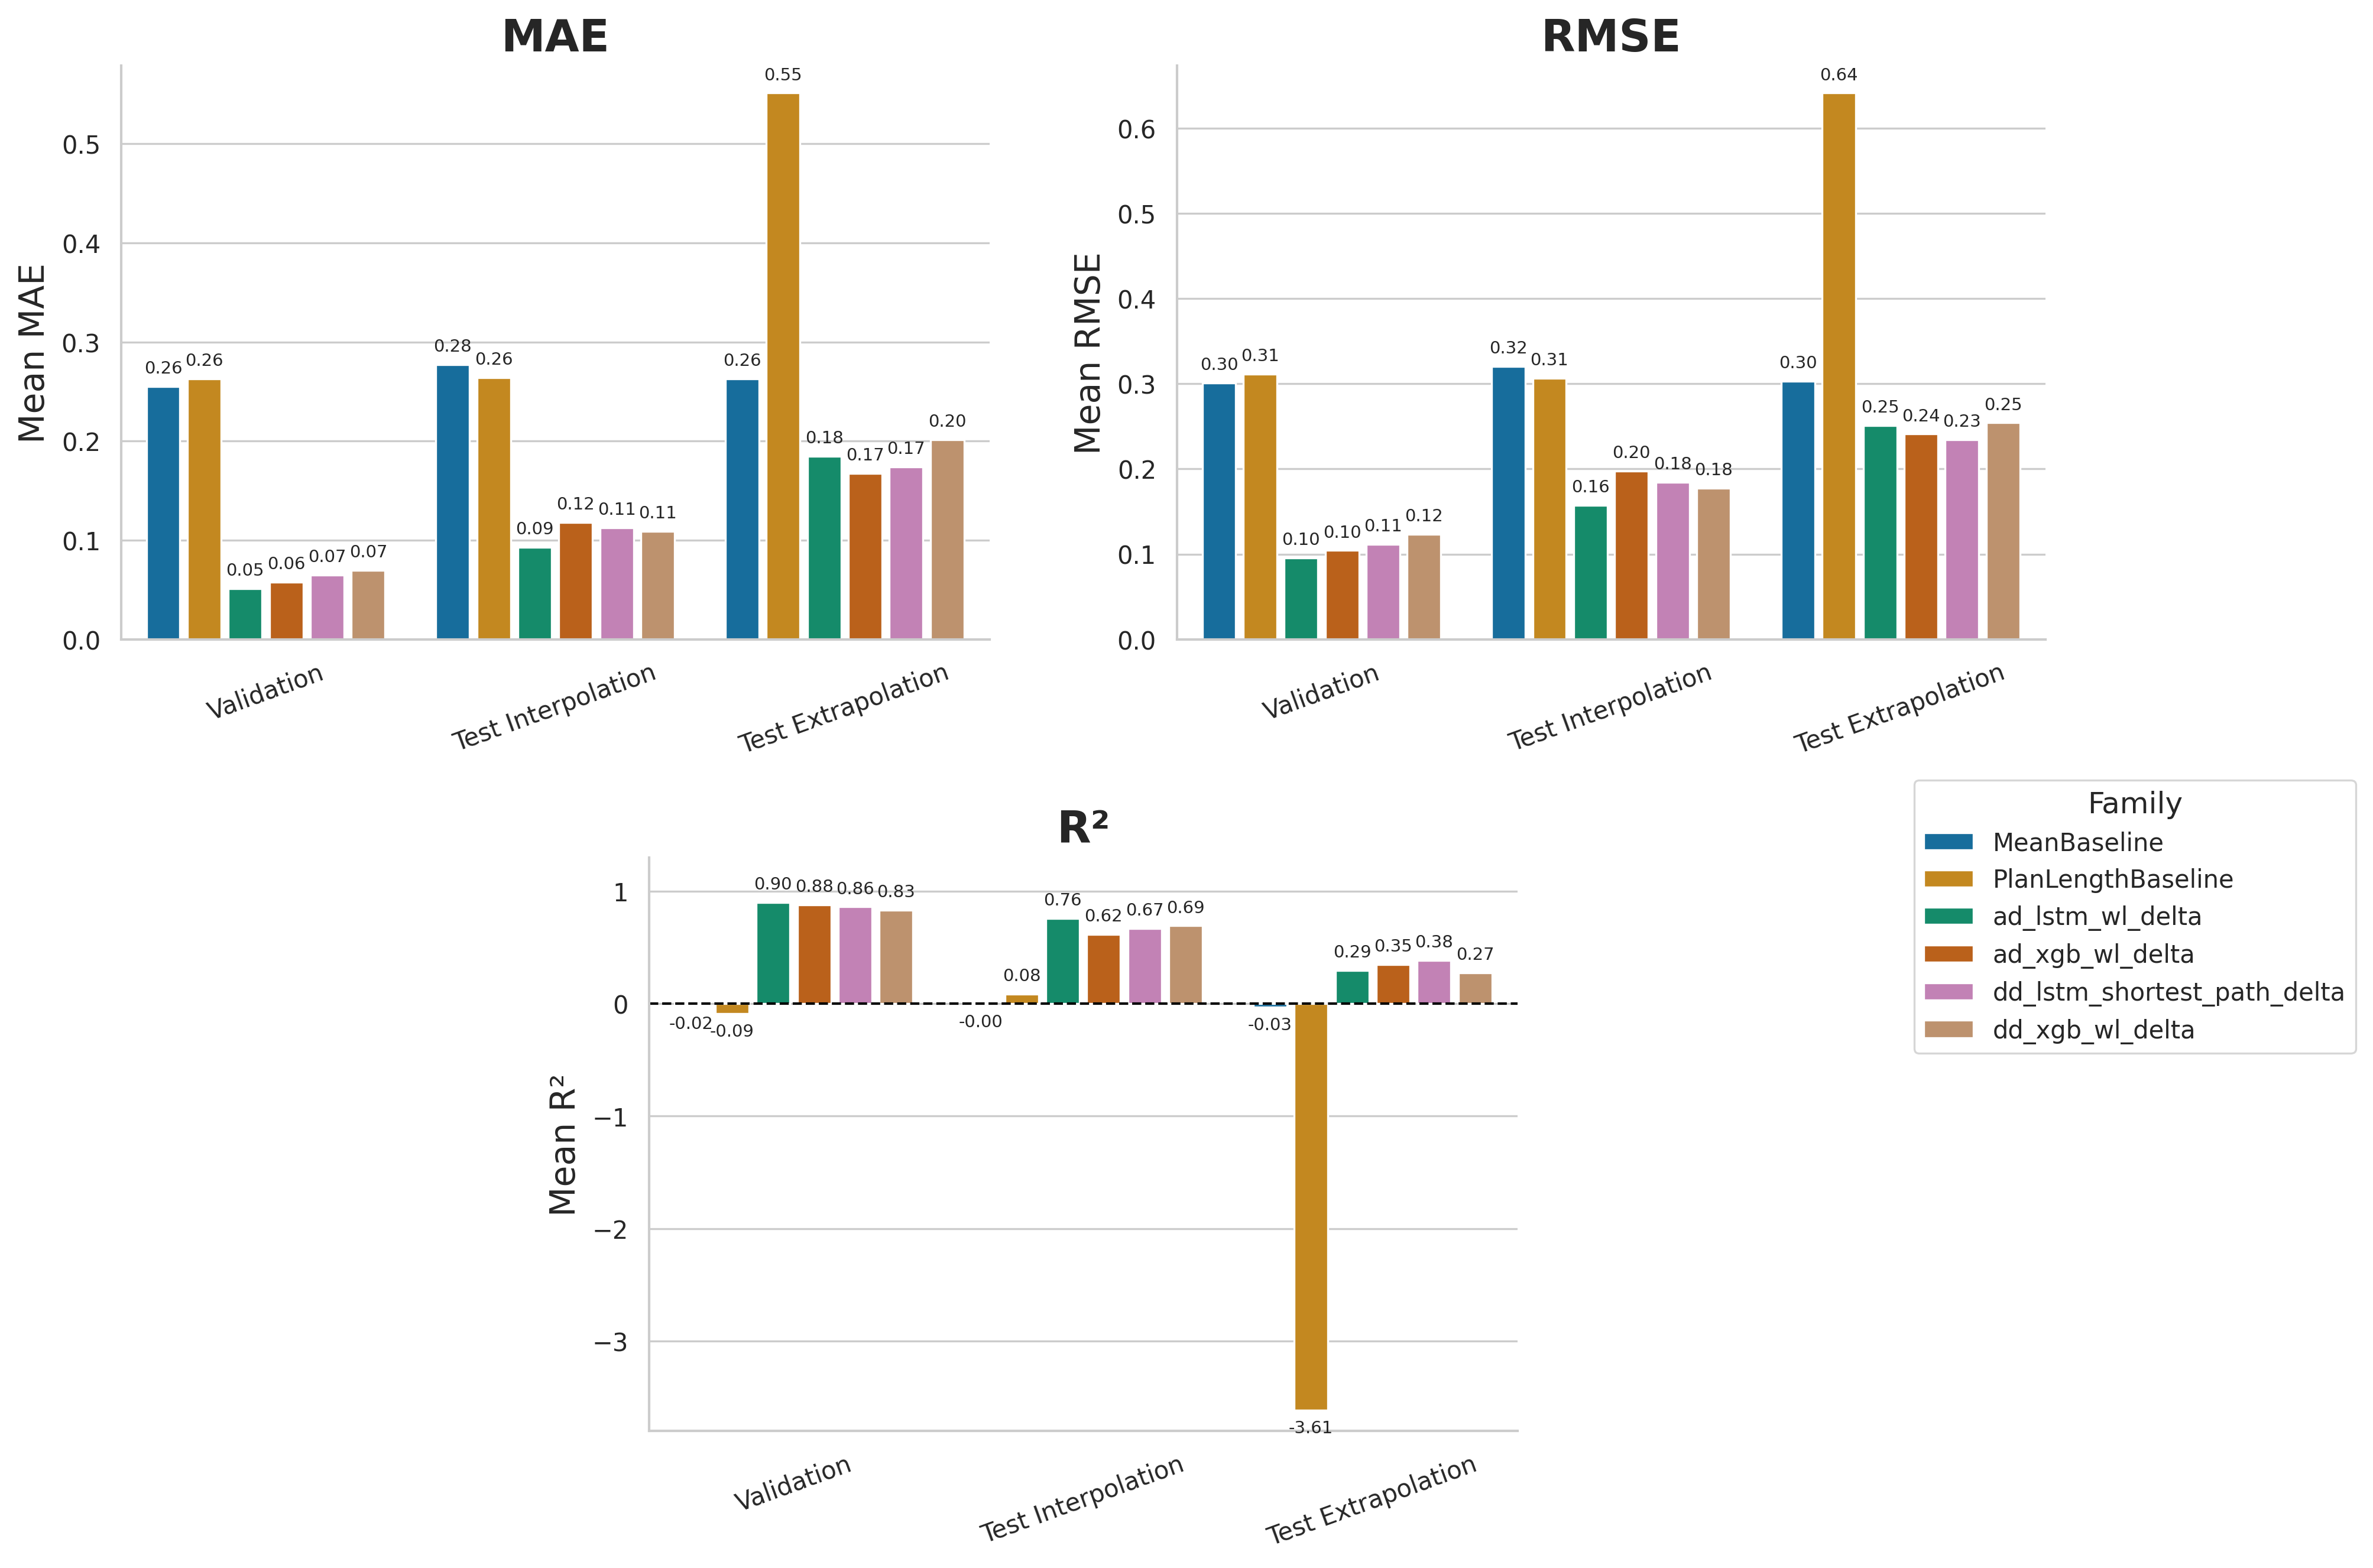

In [24]:
split_order = ["Validation", "Test Interpolation", "Test Extrapolation"]

df_test["split"] = pd.Categorical(
    df_test["split"],
    categories=split_order,
    ordered=True
)

fig = plt.figure(figsize=(14, 10))
gs = fig.add_gridspec(2, 4, hspace=0.38, wspace=0.55)

ax1 = fig.add_subplot(gs[0, :2])   # top-left (spans cols 0-1)
ax2 = fig.add_subplot(gs[0, 2:])   # top-right (spans cols 2-3)
ax3 = fig.add_subplot(gs[1, 1:3])  # bottom-center (spans cols 1-2)

# MAE plot
sns.barplot(data=df_test, x='split', y='MAE_mean', hue='family', errorbar=None, ax=ax1, width=0.85, gap=0.18)
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.2f', padding=4, fontsize=7)

ax1.set_title('MAE', fontsize=18, fontweight='bold')
ax1.set_ylabel('Mean MAE', fontsize=14)
ax1.set_xlabel('')
ax1.tick_params(axis='x', labelsize=10, rotation=20)
ax1.tick_params(axis='y', labelsize=10)

# RMSE plot
sns.barplot(data=df_test, x='split', y='RMSE_mean', hue='family', errorbar=None, ax=ax2, width=0.85, gap=0.18, legend=False)
for container in ax2.containers:
    ax2.bar_label(container, fmt='%.2f', padding=4, fontsize=7)

ax2.set_title('RMSE', fontsize=18, fontweight='bold')
ax2.set_ylabel('Mean RMSE', fontsize=14)
ax2.set_xlabel('')
ax2.tick_params(axis='x', labelsize=10, rotation=20)
ax2.tick_params(axis='y', labelsize=10)

# R² plot
sns.barplot(data=df_test, x='split', y='R2_mean', hue='family', errorbar=None, ax=ax3, width=0.85, gap=0.18, legend=False)
for container in ax3.containers:
    ax3.bar_label(container, fmt='%.2f', padding=4, fontsize=7)

ax3.axhline(0, color='black', linestyle='--', linewidth=1)

ax3.set_title('R²', fontsize=18, fontweight='bold')
ax3.set_ylabel('Mean R²', fontsize=14)
ax3.set_xlabel('')
ax3.tick_params(axis='x', labelsize=10, rotation=20)
ax3.tick_params(axis='y', labelsize=10)
ax3.set_ylim(-3.8, 1.3)

# One shared legend
handles, labels = ax1.get_legend_handles_labels()
ax1.get_legend().remove()

fig.legend(
    handles, labels,
    title='Family',
    loc='center right',
    bbox_to_anchor=(1.03, 0.4),
    fontsize=10,
    title_fontsize=12
)

plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.savefig("correctness_metrics.png", bbox_inches="tight")
plt.show()